In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':14})
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.cm import GnBu, viridis
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)


In [35]:
#results_dir = "/projects/b1094/jding/fargo/outputs/fargo/"
results_dir = "/projects/b1094/jding/fargo/outputs/fargo_nu2/"
Sigma0 = 6.4e-4

# load in sim parameters
params = {}
with open(results_dir + "variables.par") as f:
    for line in f:
       (key, val) = line.split()
       params[key] = val

# note: this excludes ghost zones
N_R = (int) (params['NY'])
N_phi = (int) (params['NX'])

i = str(100) # output number
den = np.fromfile(results_dir + "gasdens"+i+".dat").reshape(N_R,N_phi)
# velocities in guiding center frame
vR = np.fromfile(results_dir + "gasvy"+i+".dat").reshape(N_R,N_phi)
vphi = np.fromfile(results_dir + "gasvx"+i+".dat").reshape(N_R,N_phi)

In [38]:
(float) (params['DT'])

0.314159265359

In [36]:
# load in domain
Rmin = (float) (params['YMIN'])
Rmax = (float) (params['YMAX'])
phiMin = (float) (params['XMIN'])
phiMax = (float) (params['XMAX'])

Rs = np.linspace(Rmin, Rmax, num=N_R)
phis = np.linspace(phiMin, phiMax, num=N_phi)

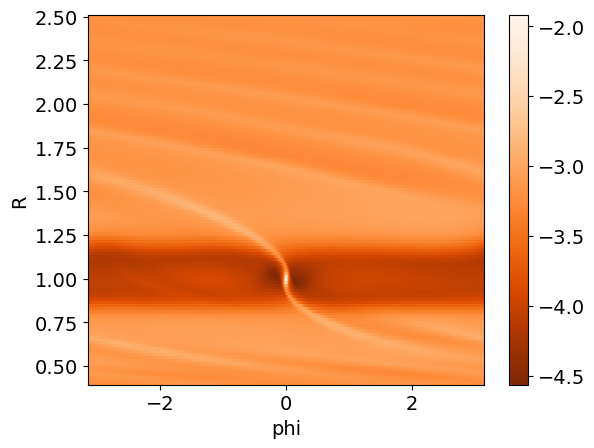

In [37]:
plt.pcolormesh(phis,Rs,np.log10(den), cmap=cm.Oranges_r)
plt.colorbar()

plt.xlabel("phi")
plt.ylabel("R")

plt.show()

## phi on y-axis, R on x-axis (like de Val-Borro+ 2006, Fig 10)

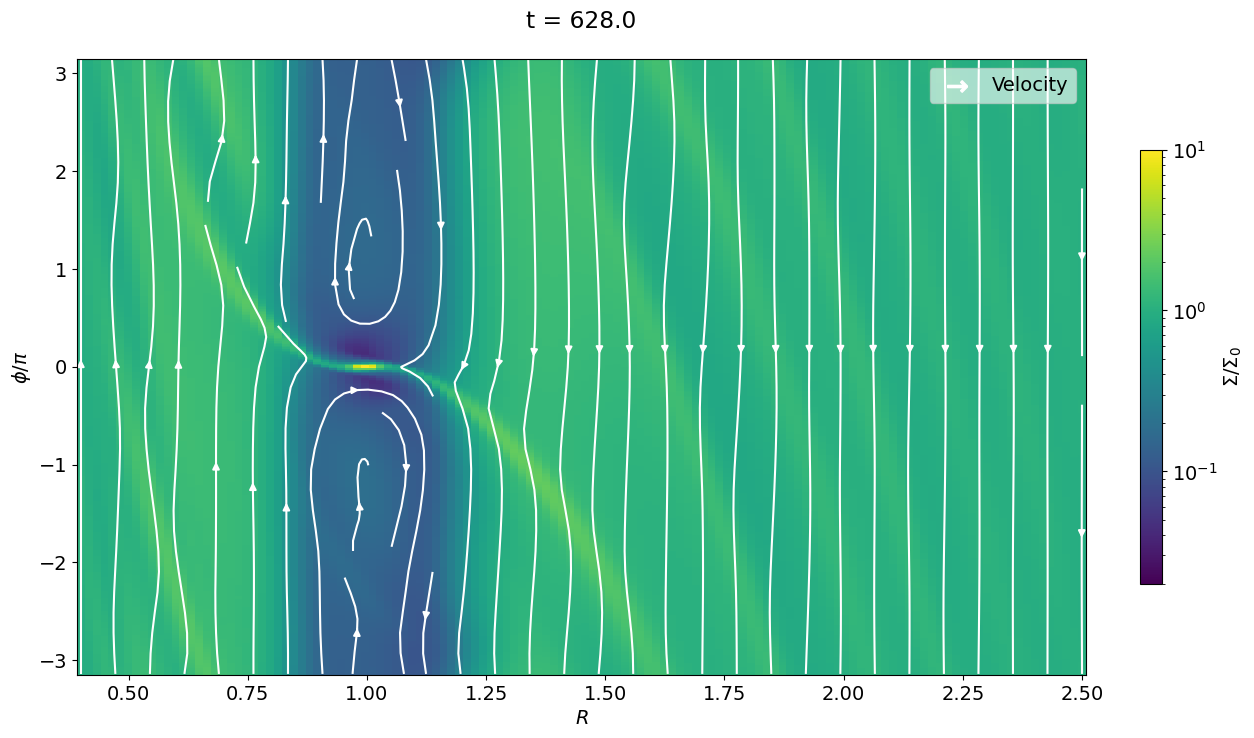

In [39]:
t_sim = 100*6.28 # ath_data['Time']

#### Read in domain ####
d_rad = Rs[1] - Rs[0]
d_phi = phis[1] - phis[0]
rad_3d, phi_3d = np.meshgrid(Rs, phis, indexing='ij')

### make figure
fig, ax = plt.subplots(1, figsize=(14,8))

# normalize Sigma by azimuthally-averaged Sigma (NOT what de Val-Borro does)
# Sigma_integrand = den*d_phi
# Sigma_avg = np.sum(Sigma_integrand,axis=1)/(2*np.pi)
# Sigma_normeds = den/Sigma_avg.reshape(len(Sigma_avg),1)

# normalize Sigma by Sigma_ss (not what de Val-Borro does?)
Sigma_normeds = den / np.reshape(Sigma0*Rs**(-1.5), (len(Rs),1))

# plot normalized sigma
kws = {'cmap': 'viridis', \
       'norm': mcolors.LogNorm(vmin=10**(-1.7), vmax=10**1)}


#c = ax.pcolormesh(rad_3d, phi_3d, Sigma_normeds, **kws)
c = ax.pcolormesh(rad_3d, phi_3d, den/Sigma0, **kws)

## velocity streamline plot
# WARNING: ax.streamplot doesn't think that rad_app is equally spaced enough,
# so I'm going to take artistic license and use an equally spaced grid instead
# (it's still accurate within .1% or so)
# ----------------------------------------------------------------------------
#v_abs = np.sqrt(vR**2 + vphi**2).T # set linewidth by |\vec{v}|
ax.streamplot(Rs, phis, vR.T, vphi.T, density=1, color='white')#, linewidth=v_abs)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
# label = r"$\Sigma/\bar{\Sigma}$"
# label = r"$\Sigma/\Sigma_{ss}$"
label = r"$\Sigma/\Sigma_0$"

plt.colorbar(c, ax=ax, label=label, pad=.05, fraction=0.02, **kws)

ax.scatter([],[],marker=r"$\rightarrow$", s=200, c='white', label="Velocity")

## set axes
ax.set_xlabel(r"$R$")
ax.set_ylabel(r"$\phi/\pi$")

#ax.set_xlim(0.6, 1.4)
# ax.set_ylim(-1, 1)

ax.set_title("t = {t_sim:.1f}".format(t_sim=t_sim),\
        y=1.05, pad=0.05)
plt.legend(framealpha=.6)

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-streamlines-Fig12-t={t:.1f}.png".format(t=t_sim),\
        bbox_inches='tight')

plt.show()

# $\Sigma$ (to compare with de Val-Borro+ 2006 Fig 12)

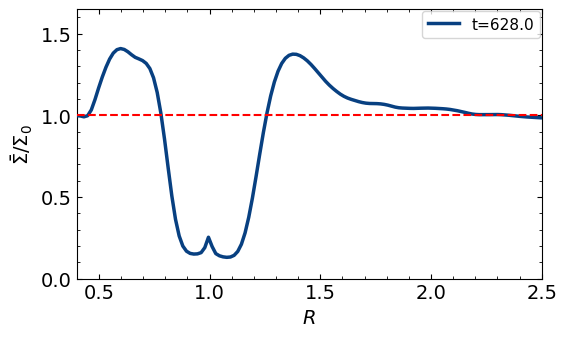

In [40]:
## Plot density, v_r, and Mdot

fig,axs = plt.subplots(1,1, figsize=(6,3.5),sharex=True,sharey=False)

#### Read in domain ####
d_rad = Rs[1] - Rs[0]
d_phi = phis[1] - phis[0]
rad_3d, phi_3d = np.meshgrid(Rs, phis, indexing='ij')

## \bar(Sigma) = azimuthally-averaged Sigma/"den", or
## \bar(Sigma)(R') = (1/2pi) * \int Sigma(R=R',phi) dphi
Sigma_integrand = den*d_phi
Sigma_avg = np.sum(Sigma_integrand[:,2:-2],axis=1)/(2*np.pi)

## Mdot(R) = mass inflow rate, or:
## Mdot(R') = \int Sigma(R=R',phi)*v_R(R',phi) (R*dphi)
Mdot_integrand = den*vR*rad_3d*d_phi
Mdot = np.sum(Mdot_integrand[:,2:-2],axis=1)

## mass-weighted v_R = Mdot / (2pi*R*\bar{Sigma}(R))
vr = Mdot / (2*np.pi*Rs*Sigma_avg)

#### Plot
zorder = 0
kws = {'c': '#084081', 'lw': 2.5, 'label': 't={:.1f}'.format(t_sim), 'zorder': zorder + 100}
Sigma_sol = Sigma0*Rs**(-1.5) # Sigma_avg[-1] * (Rs/Rs[-1])**-1.5
axs.plot(Rs,Sigma_avg/Sigma0,**kws)
#axs.plot(Rs,Sigma_avg/Sigma_sol,**kws)
#axs.loglog(rad_app,Sigma_avg,**kws)
     
#### Add Sigma=1
kws_theory = {'c': 'r', 'lw': 1.5, 'ls': '--', 'zorder': zorder+200}
axs.plot(Rs,Sigma_sol/Sigma_sol,**kws_theory)
axs.plot([],[],c='r',lw=1.5,ls='--',zorder=zorder+200)#,label='steady-state')

#### set axes
axs.set_xlabel(r'$R$')
axs.set_xlim(Rs[[0,-1]])
axs.set_ylabel(r'$\bar{\Sigma}/\Sigma_0$')
axs.set_ylim(0., 1.65)
axs.tick_params(axis='both', which='both', direction='in', top=True, right=True)

axs.xaxis.set_major_locator(MultipleLocator(0.5))
axs.xaxis.set_major_formatter('{x:.1f}')
axs.xaxis.set_minor_locator(MultipleLocator(0.1))
axs.yaxis.set_major_locator(MultipleLocator(0.5))
axs.yaxis.set_major_formatter('{x:.1f}')
axs.yaxis.set_minor_locator(MultipleLocator(0.1))

axs.legend(
    fontsize=11,
    loc='upper right',        
    #bbox_to_anchor=(0.15, 1.22, 1.02, .452), 
    ncol=2,                  
    #mode="expand",          
    borderaxespad=0.1       
)